In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

ERROR! Session/line number was not unique in database. History logging moved to new session 204


In [2]:
(img_train, lbl_train), (img_test, lbl_test) = cifar10.load_data()

print("Train images shape:", img_train.shape)
print("Test images shape: ", img_test.shape)
print("Pixel value range: ", img_train.min(), "-", img_train.max())

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 296s 2us/step
Train images shape: (50000, 32, 32, 3)
Test images shape:  (10000, 32, 32, 3)
Pixel value range:  0 - 255


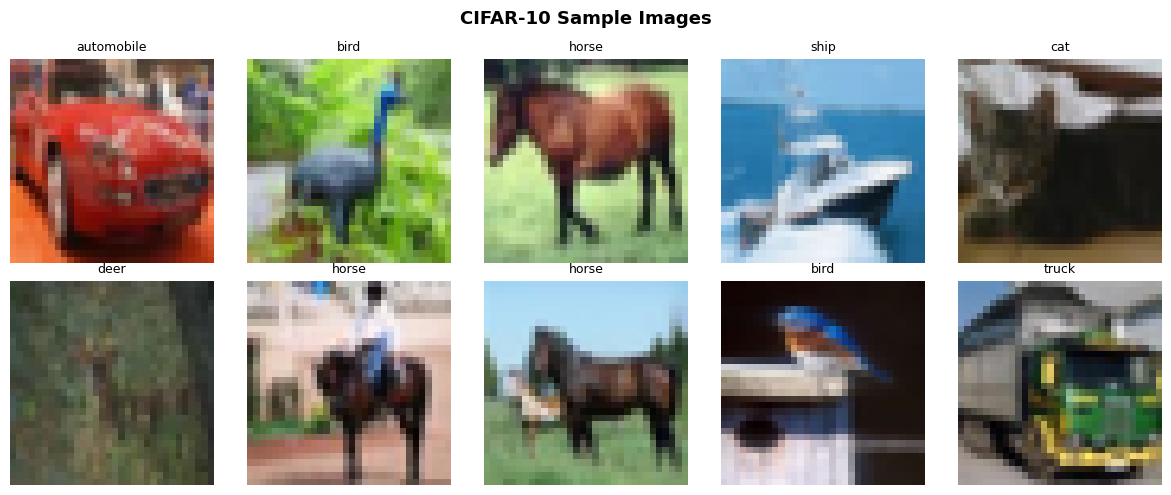

In [3]:
categories = ['airplane', 'automobile', 'bird', 'cat', 'deer',
              'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR-10 Sample Images', fontsize=13, fontweight='bold')

for idx, ax in enumerate(axes.flatten()):
    ax.imshow(img_train[idx + 5])
    ax.set_title(categories[lbl_train[idx + 5][0]], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
img_train = img_train.astype('float32') / 255.0
img_test  = img_test.astype('float32')  / 255.0

lbl_train_enc = to_categorical(lbl_train, num_classes=10)
lbl_test_enc  = to_categorical(lbl_test,  num_classes=10)

print("Normalized. New pixel range:", img_train.min(), "-", img_train.max())

Normalized. New pixel range: 0.0 - 1.0


In [5]:
X_tr, X_val, Y_tr, Y_val = train_test_split(
    img_train, lbl_train_enc,
    test_size=0.15,
    random_state=7
)

print("Training samples  :", X_tr.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples  : 42500
Validation samples: 7500


In [6]:
cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
train_log = cnn_model.fit(
    X_tr, Y_tr,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, Y_val),
    verbose=1
)

Epoch 1/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.4749 - loss: 1.4841 - val_accuracy: 0.4661 - val_loss: 1.4592
Epoch 2/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 29s 44ms/step - accuracy: 0.6126 - loss: 1.0932 - val_accuracy: 0.5715 - val_loss: 1.2245
Epoch 3/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - accuracy: 0.6796 - loss: 0.9101 - val_accuracy: 0.5640 - val_loss: 1.2400
Epoch 4/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.7178 - loss: 0.8031 - val_accuracy: 0.6331 - val_loss: 1.1136
Epoch 5/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.7531 - loss: 0.6993 - val_accuracy: 0.6796 - val_loss: 0.9563
Epoch 6/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - accuracy: 0.7810 - loss: 0.6209 - val_accuracy: 0.6804 - val_loss: 1.0056
Epoch 7/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - accuracy: 0.8034 - loss: 0.5597 - val_accuracy: 0.6309 - val_loss: 1.2605
Epoch 8/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - accuracy: 0.8271 - loss: 0.4870 - 

In [9]:
eval_loss, eval_acc = cnn_model.evaluate(img_test, lbl_test_enc, verbose=0)
print(f"Test Loss     : {eval_loss:.4f}")
print(f"Test Accuracy : {eval_acc * 100:.2f}%")

Test Loss     : 0.9785
Test Accuracy : 75.21%


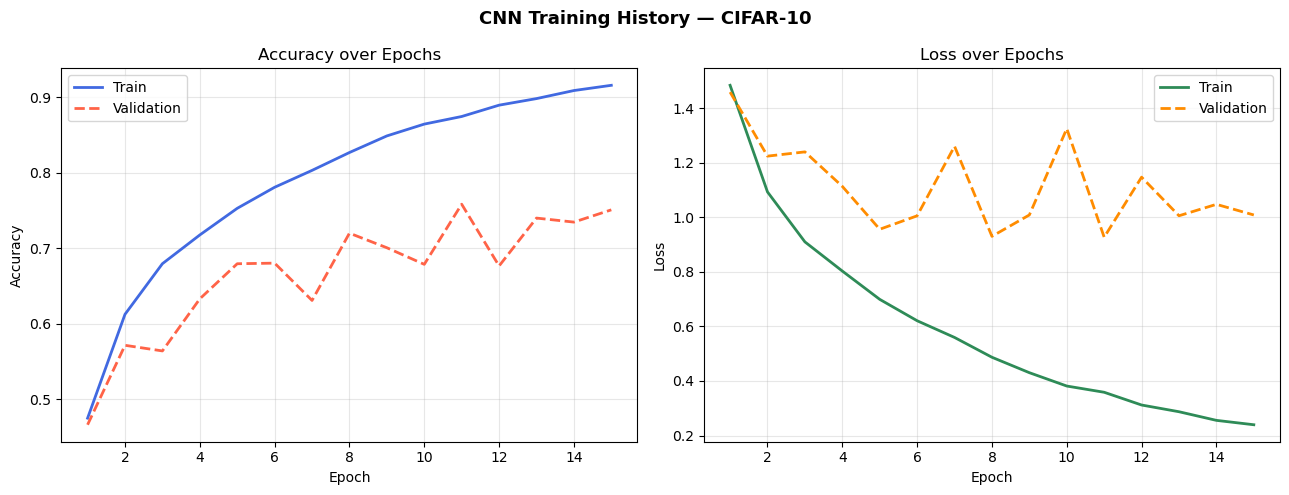

In [10]:
ep = range(1, len(train_log.history['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CNN Training History — CIFAR-10', fontsize=13, fontweight='bold')

ax1.plot(ep, train_log.history['accuracy'],    color='royalblue',  lw=2, label='Train')
ax1.plot(ep, train_log.history['val_accuracy'], color='tomato',     lw=2, linestyle='--', label='Validation')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(ep, train_log.history['loss'],     color='seagreen',   lw=2, label='Train')
ax2.plot(ep, train_log.history['val_loss'], color='darkorange',  lw=2, linestyle='--', label='Validation')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
raw_preds   = cnn_model.predict(img_test)
pred_labels = np.argmax(raw_preds, axis=1)
true_labels = np.argmax(lbl_test_enc, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


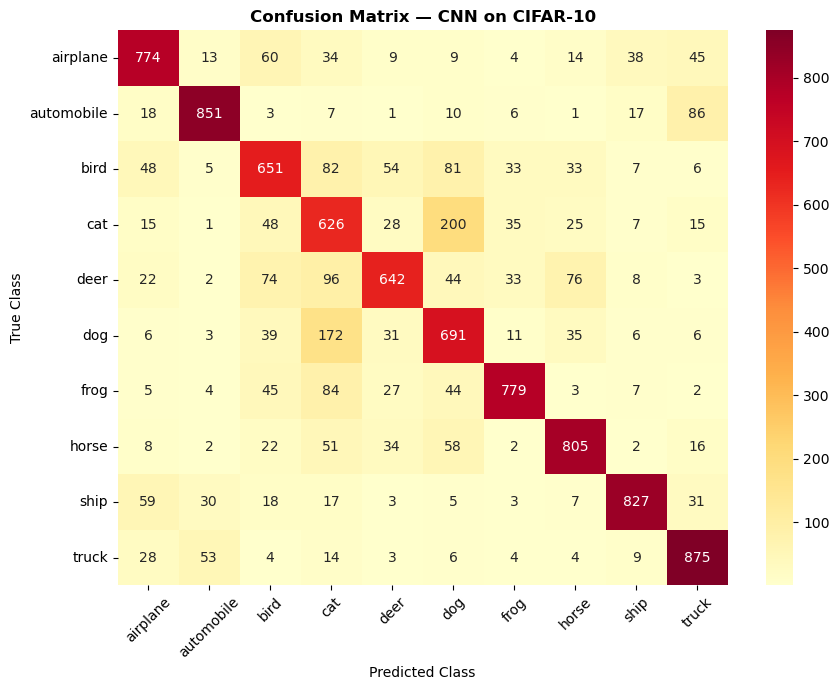

In [12]:
conf_mat = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(9, 7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix — CNN on CIFAR-10', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
print(classification_report(true_labels, pred_labels, target_names=categories))

              precision    recall  f1-score   support

    airplane       0.79      0.77      0.78      1000
  automobile       0.88      0.85      0.87      1000
        bird       0.68      0.65      0.66      1000
         cat       0.53      0.63      0.57      1000
        deer       0.77      0.64      0.70      1000
         dog       0.60      0.69      0.64      1000
        frog       0.86      0.78      0.82      1000
       horse       0.80      0.81      0.80      1000
        ship       0.89      0.83      0.86      1000
       truck       0.81      0.88      0.84      1000

    accuracy                           0.75     10000
   macro avg       0.76      0.75      0.75     10000
weighted avg       0.76      0.75      0.75     10000



In [14]:
from tensorflow.keras.applications import MobileNetV2

base = MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False

print("MobileNetV2 base loaded. Trainable:", base.trainable)
print("Total layers in base:", len(base.layers))

C:\Users\karti\AppData\Local\Temp\ipykernel_30288\2712246769.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 base loaded. Trainable: False
Total layers in base: 154


In [15]:
tl_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1, 1, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
tl_log = tl_model.fit(
    X_tr, Y_tr,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, Y_val),
    verbose=1
)

Epoch 1/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.2600 - loss: 2.0546 - val_accuracy: 0.2928 - val_loss: 1.9414
Epoch 2/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.3063 - loss: 1.9173 - val_accuracy: 0.3073 - val_loss: 1.9001
Epoch 3/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.3189 - loss: 1.8829 - val_accuracy: 0.3121 - val_loss: 1.8793
Epoch 4/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.3238 - loss: 1.8624 - val_accuracy: 0.3159 - val_loss: 1.8654
Epoch 5/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.3312 - loss: 1.8454 - val_accuracy: 0.3247 - val_loss: 1.8560
Epoch 6/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.3354 - loss: 1.8324 - val_accuracy: 0.3256 - val_loss: 1.8469
Epoch 7/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.3395 - loss: 1.8214 - val_accuracy: 0.3296 - val_loss: 1.8385
Epoch 8/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.3417 - loss: 1.8127 - 

In [17]:
tl_loss, tl_acc = tl_model.evaluate(img_test, lbl_test_enc, verbose=0)
print(f"Transfer Learning — Test Loss    : {tl_loss:.4f}")
print(f"Transfer Learning — Test Accuracy: {tl_acc * 100:.2f}%")

Transfer Learning — Test Loss    : 1.7986
Transfer Learning — Test Accuracy: 35.17%


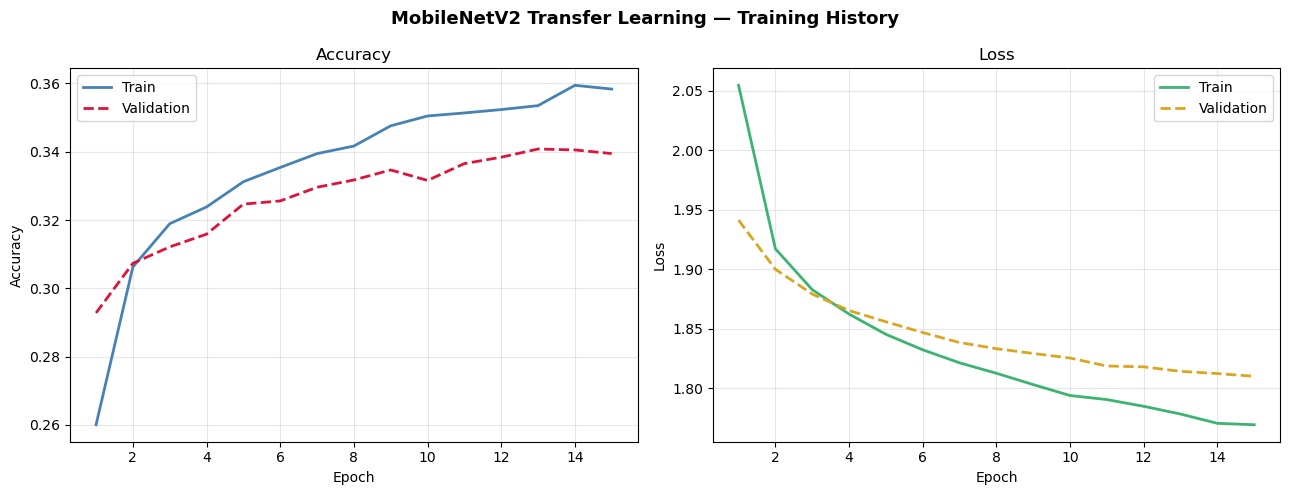

In [18]:
ep2 = range(1, len(tl_log.history['loss']) + 1)

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('MobileNetV2 Transfer Learning — Training History', fontsize=13, fontweight='bold')

ax3.plot(ep2, tl_log.history['accuracy'],    color='steelblue',  lw=2, label='Train')
ax3.plot(ep2, tl_log.history['val_accuracy'], color='crimson',    lw=2, linestyle='--', label='Validation')
ax3.set_title('Accuracy')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy')
ax3.legend()
ax3.grid(alpha=0.3)

ax4.plot(ep2, tl_log.history['loss'],     color='mediumseagreen', lw=2, label='Train')
ax4.plot(ep2, tl_log.history['val_loss'], color='goldenrod',       lw=2, linestyle='--', label='Validation')
ax4.set_title('Loss')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Loss')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()